# LECTURE 9
**Topic:** Introduction to Matrix Inversion; Gaussian Elimination  
**Textbook References:** Sections 2.4, 2.5, 2.6

---

## Key Points

- $A$ (n×n) is **nonsingular** iff $Ax=b$ has a unique solution for every $b$.
- $AA^{-1} = A^{-1}A = I$; $(A^T)^{-1}=(A^{-1})^T$; $(AB)^{-1}=B^{-1}A^{-1}$
- Triangular matrices: nonsingular iff all diagonal entries nonzero; solve by forward/backward substitution.
- **Gaussian elimination:** reduce $Ax=b$ to upper triangular $Ux=c$, then back-substitute.
- $n\times n$ system requires $n-1$ forward elimination steps.


---
## Theory and Examples

### 1-4. Nonsingularity and the Inverse

For a square $n\times n$ matrix:
- **m < n:** usually more solutions (underdetermined)
- **m > n:** usually no solution (overdetermined)
- **m = n:** usually unique solution — this is the key case

$A$ is **nonsingular** iff $Ax=b$ has a unique solution $x=A^{-1}b$ for every $b$.

### 5-6. Properties of the Inverse

- $(A^{-1})^{-1} = A$
- $AA^{-1} = A^{-1}A = I$
- $(A^T)^{-1} = (A^{-1})^T$
- $(AB)^{-1} = B^{-1}A^{-1}$ (order reverses!)

### 7-9. Special Matrices: Permutation, Diagonal, Triangular

- **Permutation:** $P^{-1} = P^T$
- **Diagonal** ($d_{ii} \neq 0$): $(D^{-1})_{ii} = 1/d_{ii}$
- **Lower triangular** $L$ (with nonzero diagonal): solve $Lx=b$ by **forward substitution**
- **Upper triangular** $U$ (with nonzero diagonal): solve $Ux=b$ by **backward substitution**


In [1]:
import numpy as np

# Inverse properties demonstration
A = np.array([[2.,1.,-1.],[4.,0.,-1.],[-8.,2.,3.]])
A_inv = np.linalg.inv(A)
print('A ='); print(A)
print('A^-1 ='); print(A_inv.round(4))
print(f'AA^-1 = I? {np.allclose(A @ A_inv, np.eye(3))}')
print(f'A^-1 A = I? {np.allclose(A_inv @ A, np.eye(3))}')

# (AT)^-1 = (A^-1)^T
lhs = np.linalg.inv(A.T)
rhs = A_inv.T
print(f'(A^T)^-1 == (A^-1)^T? {np.allclose(lhs, rhs)}')

# (AB)^-1 = B^-1 A^-1
B = np.array([[1.,0.,2.],[0.,1.,1.],[1.,1.,0.]])
lhs2 = np.linalg.inv(A @ B)
rhs2 = np.linalg.inv(B) @ np.linalg.inv(A)
print(f'(AB)^-1 == B^-1 A^-1? {np.allclose(lhs2, rhs2)}')

# Diagonal and triangular inverses
D = np.diag([2., -3., 5.])
D_inv = np.diag(1./np.diag(D))
print(f'\nDiagonal inverse: diag(1/d_ii) = diag({1./np.diag(D)})')
print(f'D D^-1 = I? {np.allclose(D @ D_inv, np.eye(3))}')

A =
[[ 2.  1. -1.]
 [ 4.  0. -1.]
 [-8.  2.  3.]]
A^-1 =
[[-0.25   0.625  0.125]
 [ 0.5    0.25   0.25 ]
 [-1.     1.5    0.5  ]]
AA^-1 = I? True
A^-1 A = I? True
(A^T)^-1 == (A^-1)^T? True
(AB)^-1 == B^-1 A^-1? True

Diagonal inverse: diag(1/d_ii) = diag([ 0.5        -0.33333333  0.2       ])
D D^-1 = I? True


---
### 10. Forward Substitution Example

Solve $Lx = b$ where:
$$L = \begin{bmatrix}2&0&0\\5&-1&0\\1&-2&3\end{bmatrix}$$

**Forward substitution** (solve top to bottom):
$$x_1 = b_1/2 \qquad x_2 = 5b_1/2 - b_2 \qquad x_3 = b_1/2 - 2x_2/3 + b_3/3$$

This gives:
$$L^{-1} = \begin{bmatrix}1/2&0&0\\5/2&-1&0\\3/2&-2/3&1/3\end{bmatrix}$$


In [2]:
from fractions import Fraction

# Forward substitution
L = np.array([[2.,0.,0.],[5.,-1.,0.],[1.,-2.,3.]])
b_sym = np.array([1.,0.,0.])  # first, test with b=[1,0,0]

def forward_substitution(L, b):
    n = len(b)
    x = np.zeros(n)
    for i in range(n):
        x[i] = (b[i] - L[i,:i] @ x[:i]) / L[i,i]
    return x

def backward_substitution(U, c):
    n = len(c)
    x = np.zeros(n)
    for i in range(n-1,-1,-1):
        x[i] = (c[i] - U[i,i+1:] @ x[i+1:]) / U[i,i]
    return x

# Compute L^-1 column by column
L_inv = np.zeros_like(L)
for j in range(3):
    ej = np.eye(3)[:,j]
    L_inv[:,j] = forward_substitution(L, ej)

print('L^-1 (from forward substitution):')
print(L_inv)
print('Expected: [[1/2,0,0],[5/2,-1,0],[3/2,-2/3,1/3]]')
print(f'L @ L^-1 = I? {np.allclose(L @ L_inv, np.eye(3))}')

L^-1 (from forward substitution):
[[ 0.5         0.          0.        ]
 [ 2.5        -1.         -0.        ]
 [ 1.5        -0.66666667  0.33333333]]
Expected: [[1/2,0,0],[5/2,-1,0],[3/2,-2/3,1/3]]
L @ L^-1 = I? True


---
### 11-14. Gaussian Elimination

To solve $Ax=b$: reduce to upper triangular form $Ux=c$, then back-substitute.

**Example:**
$$Ax = \begin{bmatrix}2&1&-1\\4&0&-1\\-8&2&3\end{bmatrix}x = \begin{bmatrix}6\\6\\-10\end{bmatrix}$$

**Step 1:** Eliminate $x_1$ from rows 2 and 3 using row 1 (pivot = 2):
- $m_{21} = 4/2 = 2$: Row 2 → Row 2 $- 2\times$ Row 1
- $m_{31} = -8/2 = -4$: Row 3 → Row 3 $- (-4)\times$ Row 1

**Step 2:** Eliminate $x_2$ from row 3 using row 2 (pivot = $-2$):
- $m_{32} = 6/(-2) = -3$: Row 3 → Row 3 $- (-3)\times$ Row 2

**Result:** $2x_3=-4\Rightarrow x_3=-2$, then back-sub: $x_2=2$, $x_1=1$.


In [3]:
def gaussian_elimination(A, b, verbose=True):
    n = len(b)
    Ab = np.column_stack([A.astype(float), b.astype(float)])
    if verbose:
        print('Augmented matrix [A|b]:')
        print(Ab)
        print()
    for j in range(n-1):
        pivot = Ab[j,j]
        if abs(pivot) < 1e-12:
            # Find nonzero pivot below
            for k in range(j+1,n):
                if abs(Ab[k,j]) > 1e-12:
                    Ab[[j,k]] = Ab[[k,j]]  # row swap
                    pivot = Ab[j,j]
                    if verbose: print(f'Row swap: rows {j} and {k}')
                    break
        if verbose: print(f'Step {j+1}: pivot = {pivot}')
        for i in range(j+1, n):
            m = Ab[i,j] / pivot
            Ab[i,:] -= m * Ab[j,:]
            if verbose: print(f'  Row {i} -= {m:.4f} * Row {j}')
        if verbose: print('  Result:'); print('  ',Ab.round(4)); print()
    U = Ab[:,:n]; c_vec = Ab[:,n]
    x = backward_substitution(U, c_vec)
    return x, U, c_vec

A = np.array([[2,1,-1],[4,0,-1],[-8,2,3]], dtype=float)
b = np.array([6,6,-10], dtype=float)
x, U, c_vec = gaussian_elimination(A, b)
print(f'Solution: x = {x}')
print(f'Verify Ax = {A @ x} (should be {b})')
print(f'numpy solution: {np.linalg.solve(A,b)}')

Augmented matrix [A|b]:
[[  2.   1.  -1.   6.]
 [  4.   0.  -1.   6.]
 [ -8.   2.   3. -10.]]

Step 1: pivot = 2.0
  Row 1 -= 2.0000 * Row 0
  Row 2 -= -4.0000 * Row 0
  Result:
   [[ 2.  1. -1.  6.]
 [ 0. -2.  1. -6.]
 [ 0.  6. -1. 14.]]

Step 2: pivot = -2.0
  Row 2 -= -3.0000 * Row 1
  Result:
   [[ 2.  1. -1.  6.]
 [ 0. -2.  1. -6.]
 [ 0.  0.  2. -4.]]

Solution: x = [ 1.  2. -2.]
Verify Ax = [  6.   6. -10.] (should be [  6.   6. -10.])
numpy solution: [ 1.  2. -2.]


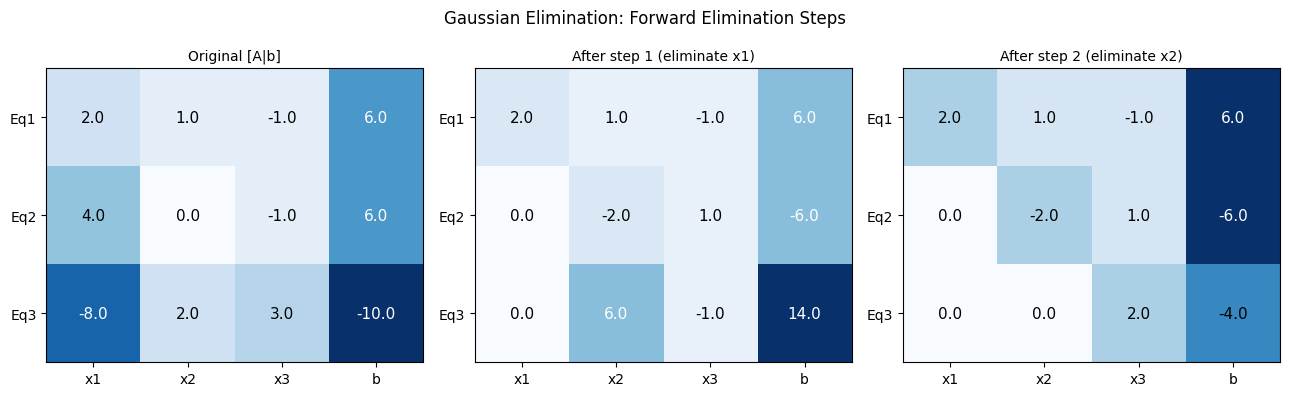

In [4]:
# Visualize Gaussian elimination process
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# Show each step as a heatmap
A = np.array([[2,1,-1,6],[4,0,-1,6],[-8,2,3,-10]], dtype=float)

steps = [A.copy()]
# Step 1: eliminate x1
A2 = A.copy()
A2[1,:] -= (A[1,0]/A[0,0]) * A[0,:]
A2[2,:] -= (A[2,0]/A[0,0]) * A[0,:]
steps.append(A2.copy())
# Step 2: eliminate x2
A3 = A2.copy()
A3[2,:] -= (A2[2,1]/A2[1,1]) * A2[1,:]
steps.append(A3.copy())

titles = ['Original [A|b]', 'After step 1 (eliminate x1)', 'After step 2 (eliminate x2)']
for ax, mat, title in zip(axes, steps, titles):
    im = ax.imshow(np.abs(mat), cmap='Blues', aspect='auto')
    for i in range(3):
        for j in range(4):
            ax.text(j,i,f'{mat[i,j]:.1f}',ha='center',va='center',fontsize=11,
                    color='white' if abs(mat[i,j])>5 else 'black')
    ax.set_xticks([0,1,2,3]); ax.set_xticklabels(['x1','x2','x3','b'])
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['Eq1','Eq2','Eq3'])
    ax.set_title(title, fontsize=10)
plt.suptitle('Gaussian Elimination: Forward Elimination Steps', fontsize=12)
plt.tight_layout(); plt.show()

---
### 15. Singularity Detection

If a **zero pivot** appears during forward elimination and **cannot be fixed by a row swap**, the matrix is **singular**:
- All remaining equations have zero coefficient for $x_j$: the matrix is singular.
- If a row swap resolves the zero pivot: continue; matrix may still be nonsingular.


In [5]:
# Demonstrate singular matrix
A_sing = np.array([[0,0,0],[0,0,0],[0,0,0]], dtype=float)
A_sing2 = np.array([[1,0,0],[0,0,0],[0,0,0]], dtype=float)
A_sing3 = np.array([[1,3,0],[2,6,0],[0,0,1]], dtype=float)

for A_s, name in [(A_sing,'[[0,0],[0,0]]'), (A_sing2,'diag(1,0,0)'), (A_sing3,'[[1,3],[2,6],[0,0,1]]')]:
    rank = np.linalg.matrix_rank(A_s)
    is_sing = (rank < A_s.shape[0])
    print(f'{name}: rank={rank}, singular={is_sing}')
    # Show Ax=0 has non-trivial solution
    if is_sing:
        null = np.linalg.svd(A_s)[2][-1]
        print(f'  Null vector (non-trivial x with Ax=0): {null.round(4)}')
        print(f'  A @ null = {(A_s @ null).round(10)}')
    print()

[[0,0],[0,0]]: rank=0, singular=True
  Null vector (non-trivial x with Ax=0): [0. 0. 1.]
  A @ null = [0. 0. 0.]

diag(1,0,0): rank=1, singular=True
  Null vector (non-trivial x with Ax=0): [0. 1. 0.]
  A @ null = [0. 0. 0.]

[[1,3],[2,6],[0,0,1]]: rank=2, singular=True
  Null vector (non-trivial x with Ax=0): [-0.9487  0.3162  0.    ]
  A @ null = [0. 0. 0.]



---
## Summary

| Concept | Formula |
|---|---|
| Nonsingular | unique $x = A^{-1}b$ for every $b$ |
| Product inverse | $(AB)^{-1}=B^{-1}A^{-1}$ |
| Diagonal inverse | $(D^{-1})_{ii}=1/d_{ii}$ |
| Forward substitution | solve $Lx=b$ top to bottom |
| Backward substitution | solve $Ux=b$ bottom to top |
| Gaussian elimination | reduce to $Ux=c$, back-substitute |

### Mistakes to Avoid
1. $(AB)^{-1} = B^{-1}A^{-1}$, NOT $A^{-1}B^{-1}$ — order reverses.
2. Zero pivot ≠ singular necessarily — check if a row swap resolves it first.
3. In forward substitution: must substitute all **previously computed** $x_i$, not just $x_{i-1}$.
